## Introduction 

In this script, the global closeness per ward is computed. 

## Reading in the Python libraries

In [48]:
from pathlib import Path

import geopandas as gpd
import momepy
import osmnx as ox
import pandas as pd
from matplotlib import pyplot as plt
from tqdm import tqdm

## Loading the data

In [49]:
BASE_DIR = Path.cwd().parent
print(BASE_DIR)

DATA_DIR = BASE_DIR / "data"
IMAGES_DIR = BASE_DIR / "images"
PROCESSED_DIR = DATA_DIR / "processed"
## LOGS_DIR = BASE_DIR / "logs"

path_graphml = DATA_DIR / "graphml_bang" / "bangalore_graphml.graphml"

# WARDS_GPKG_DIR = DATA_DIR / "gpkgs"
WARDS_G_DIR =  DATA_DIR / "g_files"

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad


In [50]:
## Detailed wards
df_inpath = PROCESSED_DIR / "bang_fix_mapshaper.shp"
print(df_inpath)

C:\Ellen\personal\projects\geospatial\lst_bang_chennai\lstroad\data\processed\bang_fix_mapshaper.shp


In [51]:
df = gpd.read_file(df_inpath)
df.head()

,ward_id,ward_name,Corporatio,geometry
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,..."
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13..."
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262..."
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,..."
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727..."


In [52]:
print(f'There are {df.shape[0]} wards in the dataset.')

There are 369 wards in the dataset.


Reading in the entire Bangalore network data that we had downloaded earlier as again we will "truncate" the network to the different street networks at the ward level:

In [53]:
G = ox.io.load_graphml(path_graphml)

In [54]:
G.graph["crs"]

'epsg:4326'

In [55]:
df.crs.to_epsg()

4326

## Computing (global) closeness at the ward level

In [56]:
results = pd.DataFrame(columns=['ward_id', 'ward_name', 'Corporatio', 'closeness'])
results

,ward_id,ward_name,Corporatio,closeness


In [57]:
## for ward in tqdm(range(0,5), desc="Processing wards"):
for ward in tqdm(range(0,len(df)), desc = "Processing wards"):

    ## print(f'Processing the {ward} ward.')

    id_ward = df['ward_id'].iloc[ward]
    name_ward = df['ward_name'].iloc[ward]
    corporation = df['Corporatio'].iloc[ward]
    
    ## print(name_ward)

    df_ward = df.iloc[[ward]]

    ## ward_geometry = df.iloc[ward,:].geometry
    ward_geometry = df_ward.geometry.iloc[0]

    ## https://docs.momepy.org/en/stable/user_guide/simple/shape.html#Street-network-shapes
    G_clipped = ox.truncate.truncate_graph_polygon(G, ward_geometry)

    streets_graph = ox.projection.project_graph(G_clipped)

    edges = ox.graph_to_gdfs(
    ox.convert.to_undirected(streets_graph),
    nodes=False,
    edges=True,
    node_geometry=False,
    fill_edge_geometry=True,
    )

    primal = momepy.gdf_to_nx(edges, approach="primal")

    primal = momepy.closeness_centrality(primal, name='closeness_global', weight='mm_len')

    nodes = momepy.nx_to_gdf(primal, lines=False)

    closeness_mean = nodes['closeness_global'].mean()

    results.loc[ward] = [
        id_ward,
        name_ward,
        corporation,
        closeness_mean
    ]
    

Processing wards: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 369/369 [1:13:00<00:00, 11.87s/it]


In [58]:
results

,ward_id,ward_name,Corporatio,closeness
0,25,25 - Vinayaka Layout,West,0.000769
1,2,2 - Aerocity,North,0.000296
2,3,3 - Chowdeshwari ward,North,0.000380
3,15,15 - Ramamurthy Nagara,East,0.001307
4,58,58 - Nagashettyhalli,North,0.001277
...,...,...,...,...
364,56,56 - Gopalpura,Central,0.000881
365,57,57 - Cottonpete,Central,0.001330
366,54,54 - Binnypete,Central,0.001074
367,47,47 - IPD Salappa Ward,Central,0.001231


In [59]:
top10_highest = (
    results
    .sort_values(by='closeness', ascending=False)
    .head(10)
)
top10_highest

,ward_id,ward_name,Corporatio,closeness
274,39,39 - Venkat Reddy Nagara,Central,0.002948
258,46,46 - Cheluvadi Palya,Central,0.002837
184,88,88 - Sangolli Rayanna Ward,West,0.002800
233,28,28 - Neelasandra,Central,0.002742
26,51,51 - Old Guddadahalli,Central,0.002735
159,65,65 - Manjunath Nagara,West,0.002709
42,3,3 - Yarab nagar,South,0.002670
198,58,58 - Dayanand Nagara,West,0.002637
60,52,52 - Padarayanapura,Central,0.002630
235,55,55 - Bhuvaneshwari Nagar,Central,0.002612


In [60]:
top10_lowest = (
    results
    .sort_values(by='closeness', ascending=True)
    .head(10)
)
top10_lowest

,ward_id,ward_name,Corporatio,closeness
238,50,50 - Gunjur,East,0.000196
71,37,37 - Yelenahalli,South,0.000243
7,24,24 - Agaram,Central,0.000244
18,20,20 - Kengeri Kote ward,West,0.000249
74,28,28 - Byrathi,East,0.000255
91,6,6 - Doddabettahalli,North,0.000260
90,34,34 - Chikkathoguru,South,0.000276
34,2,2 - Horamavu,East,0.000278
5,21,21 - Kogilu,North,0.000287
1,2,2 - Aerocity,North,0.000296


In [61]:
print(f'The mean of the global closeness across the wards is {results["closeness"].mean()}.')
print(f'The minimum of the global closeness across the wards is {results["closeness"].min()}.')
print(f'The maximum of the global closeness across the wards is {results["closeness"].max()}.')

The mean of the global closeness across the wards is 0.0010706848068617525.
The minimum of the global closeness across the wards is 0.00019648446157627424.
The maximum of the global closeness across the wards is 0.002947745491890953.


In [62]:
## Save this:
results_path = PROCESSED_DIR / "results_bangalore_global_closeness_all_roads.csv"

results.to_csv(results_path)

In [64]:
# You can normally do things from results but I had to read them in later
results_path = PROCESSED_DIR / "results_bangalore_global_closeness_all_roads.csv"
results = pd.read_csv(results_path)

In [65]:
results = pd.read_csv(results_path)
results

,Unnamed: 0,ward_id,ward_name,Corporatio,closeness
0,0,25,25 - Vinayaka Layout,West,0.000769
1,1,2,2 - Aerocity,North,0.000296
2,2,3,3 - Chowdeshwari ward,North,0.000380
3,3,15,15 - Ramamurthy Nagara,East,0.001307
4,4,58,58 - Nagashettyhalli,North,0.001277
...,...,...,...,...,...
364,364,56,56 - Gopalpura,Central,0.000881
365,365,57,57 - Cottonpete,Central,0.001330
366,366,54,54 - Binnypete,Central,0.001074
367,367,47,47 - IPD Salappa Ward,Central,0.001231


In [66]:
df_merged = df.merge(results, on = 'ward_name')
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,Unnamed: 0,ward_id_y,Corporatio_y,closeness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0,25,West,0.000769
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",1,2,North,0.000296
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",2,3,North,0.000380
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",3,15,East,0.001307
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",4,58,North,0.001277
...,...,...,...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",364,56,Central,0.000881
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",365,57,Central,0.001330
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",366,54,Central,0.001074
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",367,47,Central,0.001231


In [67]:
df_merged = df_merged[['ward_id_x', 'ward_name', 'Corporatio_x', 'geometry', 'closeness']]
df_merged

,ward_id_x,ward_name,Corporatio_x,geometry,closeness
0,25,25 - Vinayaka Layout,West,"POLYGON ((77.5033 12.95788, 77.50446 12.96083,...",0.000769
1,2,2 - Aerocity,North,"MULTIPOLYGON (((77.62561 13.10441, 77.62559 13...",0.000296
2,3,3 - Chowdeshwari ward,North,"POLYGON ((77.58519 13.13277, 77.58513 13.13262...",0.000380
3,15,15 - Ramamurthy Nagara,East,"POLYGON ((77.6749 13.01648, 77.67503 13.01647,...",0.001307
4,58,58 - Nagashettyhalli,North,"POLYGON ((77.57276 13.04724, 77.57339 13.04727...",0.001277
...,...,...,...,...,...
364,56,56 - Gopalpura,Central,"POLYGON ((77.56157 12.9827, 77.56202 12.98266,...",0.000881
365,57,57 - Cottonpete,Central,"POLYGON ((77.5726 12.97301, 77.57258 12.97297,...",0.001330
366,54,54 - Binnypete,Central,"POLYGON ((77.55852 12.96509, 77.55842 12.96521...",0.001074
367,47,47 - IPD Salappa Ward,Central,"POLYGON ((77.55533 12.96444, 77.55574 12.96432...",0.001231


In [68]:
# Rename the columns
df_merged = df_merged.rename(columns={
    'ward_id_x': 'ward_id',
    'Corporatio_x': 'Corporatio'
})

## Plots

The ward with the highest straightness

In [83]:
## Path to save the figure:
fig_path = IMAGES_DIR / 'closeness_global_all_roads_bangalore.png'

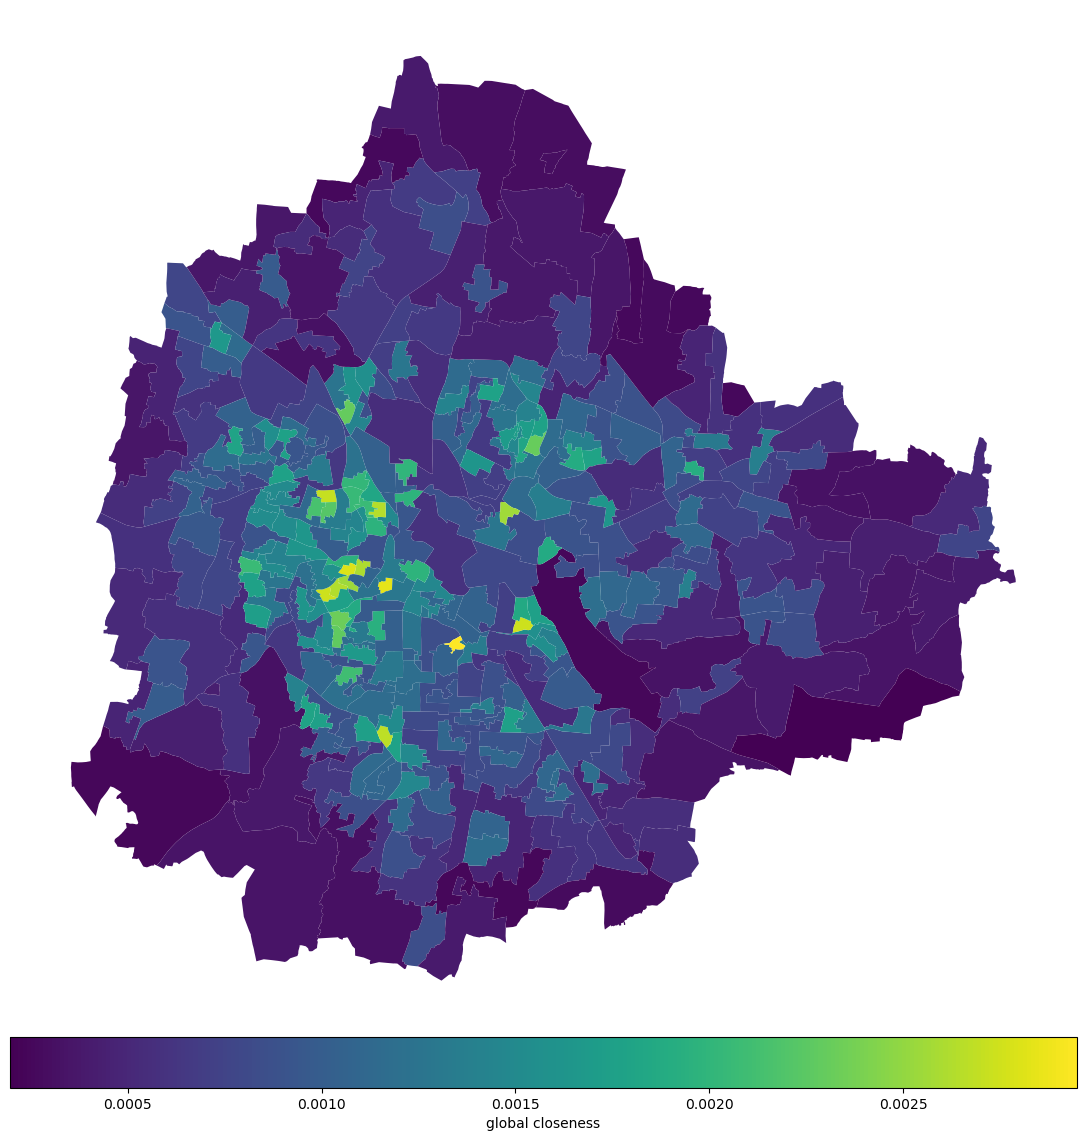

In [84]:
import matplotlib.pyplot as plt

from mpl_toolkits.axes_grid1 import make_axes_locatable

fig, ax = plt.subplots(1, 1, figsize=(14, 14))

divider = make_axes_locatable(ax)

cax = divider.append_axes("bottom", size="5%", pad=0.1)

df_merged.plot(
    column="closeness",
    ax=ax,
    legend=True,
    cax=cax,
    legend_kwds={"label": "global closeness", "orientation": "horizontal"},
)
ax.set_axis_off()
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

plt.show()